# Lab 3: NAIP imagery, NDVI and vegetation cover at the census tract level
**Name:** Qiwen Bian  **Date:** 2026-09-09  
**Study city**: Chicago, IL

This notebook generates the NDVI map and the vegetation cover map at the census tract level in Chicago, following the same workflow as the Philadelphia demo, organized into the five required steps:

(1) Collect the city limit and census tract files | `chicago_limit_4326.shp`, `chicago_limit_proj.shp`, `chicago-tract-26916.shp` |  
(2) Download the NAIP tiles and mosaic them | `cir-naip/*.tif` (34 tiles), `data/naip-chicago-mosaic.tif` |  
(3) Mask out the pixels outside the city boundary | `data/naip-chicago-masked.tif` |  
(4) Calculate NDVI and the vegetation cover map | `data/veg-tiles/*.tif` |  
(5) Census-tract-level NDVI / vegetation cover maps | `data/chicago-vegcover-tract.shp` + two choropleth maps |

**Data**  
(1) NAIP 2017: aerial imagery (1 m, 4-band), summer flight `2017-09-03`, downloaded from the
  Microsoft Planetary Computer STAC API with `pystac-client` (notebook 3-1's method).  
(2) TIGER/Line 2025: shapefiles from the U.S. Census Bureau: `PLACE` layer (city limit) and
  `TRACT` layer (census tracts), both for Illinois (FIPS 17).

**Chicago-specific corrections**

(1) UTM zone: Philadelphia sits in UTM zone 18N (`EPSG:26918`), but Chicago's longitude
   (-87.9° to -87.5°) is in `zone 16N`, so the projected city limit uses `EPSG:26916` —
   which is also the CRS of the Illinois NAIP tiles themselves.  
(2) Band order: The Planetary Computer NAIP tiles store bands as `R, G, B, NIR`
   (verified visually in step 2.4), so NDVI uses `red = read(1)`, `nir = read(4)`.
   The Philadelphia demo code assumed the older CIR order (`nir = read(1)`), which would give
   an inverted NDVI here.

## Step 1: Collect the city limit file and the census tract file

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import fiona
from shapely.geometry import shape, box, mapping

print('rasterio:', rasterio.__version__, '| geopandas:', gpd.__version__)

rasterio: 1.3.8 | geopandas: 0.13.2


In [2]:
place = gpd.read_file('data/tl_2025_17_place.shp')
chi = place[place['NAME'] == 'Chicago']
print('features kept:', len(chi), '| original CRS:', place.crs.to_string())

chi.to_crs('EPSG:4326').to_file('data/chicago_limit_4326.shp')
chi.to_crs('EPSG:26916').to_file('data/chicago_limit_proj.shp')

print('city area:', round(chi.to_crs(26916).geometry.area.iloc[0] / 1e6, 1), 'km2')
print('bounds (lon/lat):', chi.to_crs(4326).total_bounds.round(4))

features kept: 1 | original CRS: EPSG:4269
city area: 607.0 km2
bounds (lon/lat): [-87.9401  41.6443 -87.5237  42.0231]


In [3]:
tracts = gpd.read_file('data/tl_2025_17_tract.shp')
print('tracts in Illinois:', len(tracts))

city_geom = chi.to_crs(4326).geometry.iloc[0]
chi_tracts = tracts[tracts.intersects(city_geom)].to_crs('EPSG:26916')
chi_tracts = chi_tracts[chi_tracts['GEOID'] != '17031990000'] 
chi_tracts.to_file('data/chicago-tract-26916.shp')

print('tracts intersecting Chicago:', len(chi_tracts))

tracts in Illinois: 3265
tracts intersecting Chicago: 839


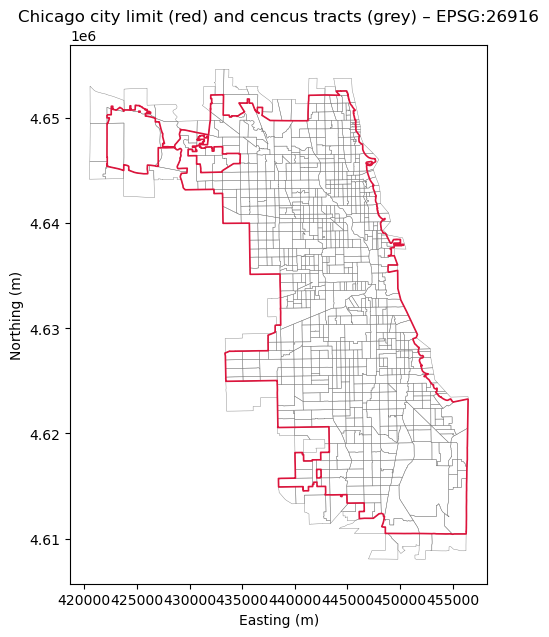

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
chi_tracts.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.3)
chi.to_crs(26916).plot(ax=ax, facecolor='none', edgecolor='crimson', linewidth=1.2)
ax.set_title('Chicago city limit (red) and cencus tracts (grey) – EPSG:26916')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
plt.show()

## Step 2: Download the NAIP tiles and mosaic them

### 1. Define the area of interest

In [5]:
shpfile = 'data/chicago_limit_4326.shp'

with fiona.open(shpfile) as lyr:
    print('CRS of the input file:', lyr.crs.to_string())
    print('Number of features:', len(lyr))
    city_parts = [shape(feat['geometry']) for feat in lyr]
    left, bottom, right, top = lyr.bounds

print('\nBounding box (lon/lat):', (round(left, 4), round(bottom, 4), round(right, 4), round(top, 4)))
area_of_interest = mapping(box(left, bottom, right, top))

CRS of the input file: EPSG:4326
Number of features: 1

Bounding box (lon/lat): (-87.9401, 41.6443, -87.5237, 42.0231)


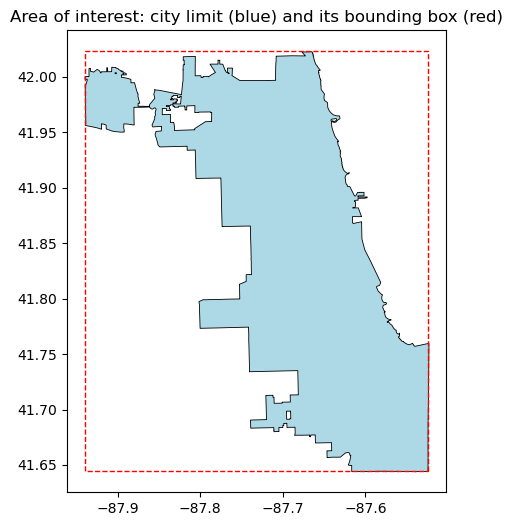

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
gpd.read_file(shpfile).plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.6)
gpd.GeoSeries([box(left, bottom, right, top)], crs='EPSG:4326').boundary.plot(
    ax=ax, color='red', linestyle='--', linewidth=1)
ax.set_title('Area of interest: city limit (blue) and its bounding box (red)')
plt.show()

### 2. Search the Planetary Computer catalog

In [7]:
import pystac_client
import planetary_computer as pc
import urllib.request

In [8]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace,
)

startDate, endDate = '2017-06-01', '2017-09-30'
range_time = f'{startDate}/{endDate}'

search = catalog.search(
    collections=['naip'],
    intersects=area_of_interest,
    datetime=range_time,
)
items_tiles = search.item_collection()
print(f'{len(items_tiles)} NAIP tiles found for {range_time}')

item = items_tiles[0]
print('id:', item.id)
print('date:', item.datetime.date())
print('gsd:', item.properties.get('gsd'), 'm')
print('EPSG:', item.properties.get('proj:epsg'))

50 NAIP tiles found for 2017-06-01/2017-09-30
id: il_m_4208759_sw_16_1_20170903_20170927
date: 2017-09-03
gsd: 1.0 m
EPSG: None


In [9]:
keep = [it for it in items_tiles
        if any(shape(it.geometry).intersects(part) for part in city_parts)]
print(f'{len(keep)} of them actually intersect Chicago '
      f'({len(items_tiles) - len(keep)} bounding-box-only tiles skipped)')

MB_PER_TILE = 195
print(f'estimated download: {len(keep)} x ~{MB_PER_TILE} MB = ~{len(keep)*MB_PER_TILE/1000:.1f} GB')

34 of them actually intersect Chicago (16 bounding-box-only tiles skipped)
estimated download: 34 x ~195 MB = ~6.6 GB


### 3. Download the tiles

In [10]:
outfolder = 'cir-naip'
os.makedirs(outfolder, exist_ok=True)

downloaded = []
for n, it in enumerate(keep, start=1):
    outfilename = os.path.join(outfolder, it.id + '.tif')
    if os.path.exists(outfilename):
        downloaded.append(outfilename)
        continue
    print(f'[{n}/{len(keep)}] downloading {it.id} ...')
    urllib.request.urlretrieve(it.assets['image'].href, outfilename)
    downloaded.append(outfilename)

print(f'\n{len(downloaded)} tiles available in {outfolder}/')

[1/34] downloading il_m_4208759_sw_16_1_20170903_20170927 ...
[2/34] downloading il_m_4208759_se_16_1_20170903_20170927 ...
[3/34] downloading il_m_4208758_sw_16_1_20170903_20170927 ...
[4/34] downloading il_m_4208758_se_16_1_20170903_20170927 ...
[5/34] downloading il_m_4208757_sw_16_1_20170903_20170927 ...
[6/34] downloading il_m_4208757_se_16_1_20170903_20170927 ...
[7/34] downloading il_m_4108720_sw_16_1_20170903_20170927 ...
[8/34] downloading il_m_4108720_nw_16_1_20170903_20170927 ...
[9/34] downloading il_m_4108720_ne_16_1_20170903_20170927 ...
[10/34] downloading il_m_4108719_se_16_1_20170903_20170927 ...
[11/34] downloading il_m_4108719_nw_16_1_20170903_20170927 ...
[12/34] downloading il_m_4108719_ne_16_1_20170903_20170927 ...
[13/34] downloading il_m_4108712_sw_16_1_20170903_20170927 ...
[14/34] downloading il_m_4108712_se_16_1_20170903_20170927 ...
[15/34] downloading il_m_4108712_nw_16_1_20170903_20170927 ...
[16/34] downloading il_m_4108711_sw_16_1_20170903_20170927 ...
[

### 4. Look at one tile and verify the band order

In [11]:
tiffile = sorted(glob.glob(os.path.join('cir-naip', '*.tif')))[0]
naip_dataset = rasterio.open(tiffile)

print('file:', os.path.basename(tiffile))
print('band:', naip_dataset.count, naip_dataset.dtypes)
print('size:', naip_dataset.width, 'x', naip_dataset.height)
print('CRS:', naip_dataset.crs, '| resolution:', naip_dataset.res)
naip_dataset.meta

file: il_m_4108701_ne_16_1_20170816_20170927.tif
band: 4 ('uint8', 'uint8', 'uint8', 'uint8')
size: 5854 x 7596
CRS: EPSG:26916 | resolution: (1.0, 1.0)


{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 5854,
 'height': 7596,
 'count': 4,
 'crs': CRS.from_epsg(26916),
 'transform': Affine(1.0, 0.0, 421982.0,
        0.0, -1.0, 4650502.0)}

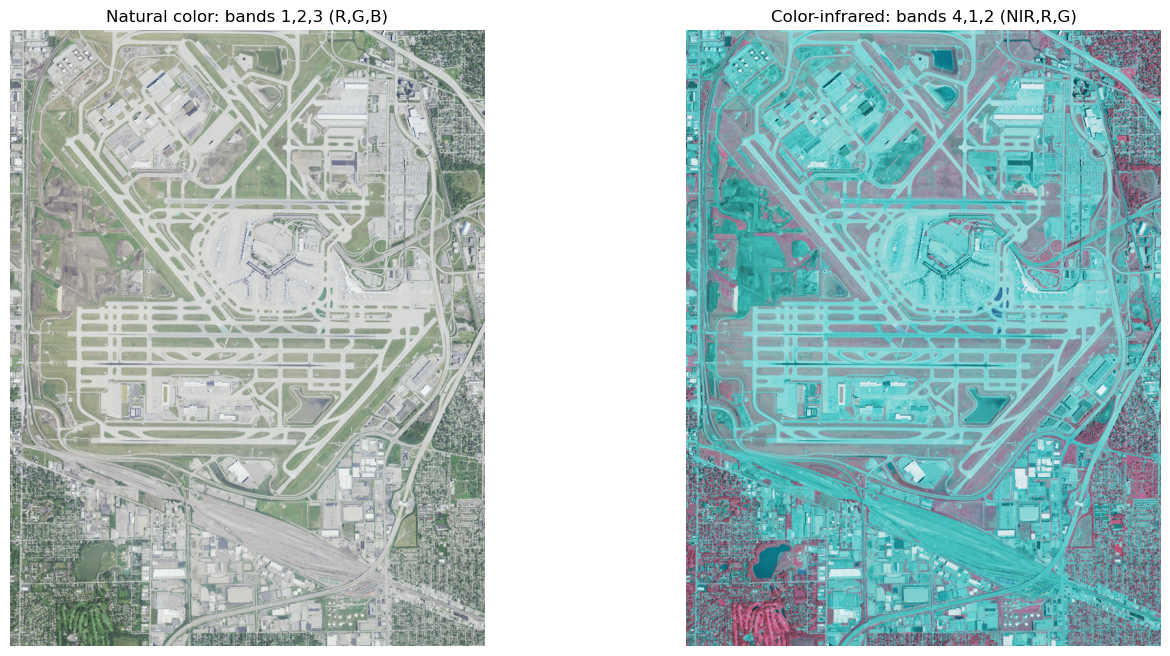

mean NDVI with red=b1, nir=b4: -267743.365 (positive = correct order)


In [12]:
f = 8
h, w = naip_dataset.height // f, naip_dataset.width // f
r = naip_dataset.read(1, out_shape=(h, w))
g = naip_dataset.read(2, out_shape=(h, w))
b = naip_dataset.read(3, out_shape=(h, w))
n = naip_dataset.read(4, out_shape=(h, w))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(np.dstack([r,g,b]))
axes[0].set_title('Natural color: bands 1,2,3 (R,G,B)')
axes[1].imshow(np.dstack([n,r,g]))
axes[1].set_title('Color-infrared: bands 4,1,2 (NIR,R,G)')
for ax in axes: ax.axis('off')
plt.show()

red, nir = naip_dataset.read(1), naip_dataset.read(4)
ndvi_check = (nir.astype(np.float32) - red) / (nir + red +1e-6)
print(f'mean NDVI with red=b1, nir=b4: {ndvi_check.mean():.3f} (positive = correct order)')

### 5. Mosaic the tiles into one raster

In [13]:
from rasterio.merge import merge

inputfolder = 'cir-naip'
outfile = 'data/naip-chicago-mosaic.tif'

tiflist = sorted(glob.glob(os.path.join(inputfolder, '*.tif')))
src_files_to_mosaic = [rasterio.open(fp) for fp in tiflist]
print('mosaicking', len(src_files_to_mosaic), 'tiles ...')

merge(src_files_to_mosaic,
     dst_path=outfile,
     dst_kwds={'compress': 'lzw', 'BIGTIFF': 'YES'})

for src in src_files_to_mosaic:
    src.close()

with rasterio.open(outfile) as mos:
    print('mosaic:', mos.width, 'x', mos.height, '| bands:', mos.count,
         '| CRS:', mos.crs, '| size: %.1f GB' % (os.path.getsize(outfile) / 1e9))

mosaicking 34 tiles ...
mosaic: 41971 x 49539 | bands: 4 | CRS: EPSG:26916 | size: 5.9 GB


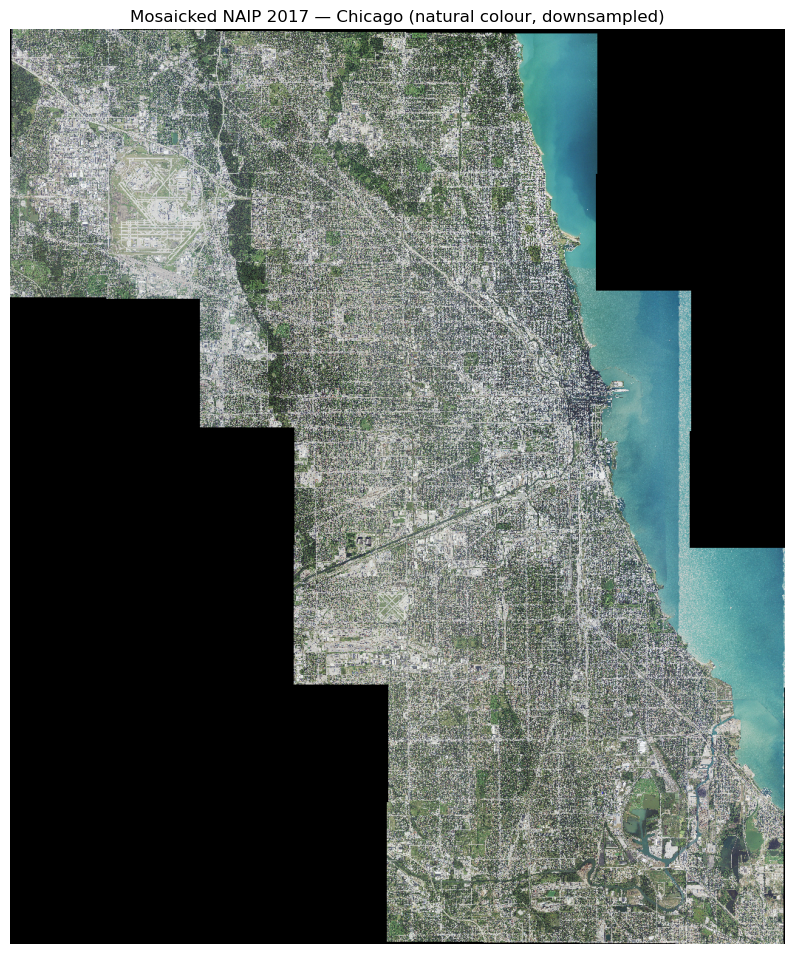

In [14]:
with rasterio.open(outfile) as mos:
    f = 40
    h, w = mos.height // f, mos.width // f
    rgb = np.dstack([mos.read(1, out_shape=(h, w)),
                     mos.read(2, out_shape=(h, w)),
                     mos.read(3, out_shape=(h, w))])

plt.figure(figsize=(10, 12))
plt.imshow(rgb)
plt.title('Mosaicked NAIP 2017 — Chicago (natural colour, downsampled)')
plt.axis('off')
plt.show()

## Step 3: Mask out the pixels outside the city boundary

In [15]:
from rasterio.mask import mask

input_value_raster = 'data/naip-chicago-mosaic.tif'
shpfile = 'data/chicago_limit_proj.shp'
out_raster = 'data/naip-chicago-masked.tif'

with fiona.open(shpfile, 'r') as shapefile:
    shapes = [feature['geometry'] for feature in shapefile]

with rasterio.open(input_value_raster) as src:
    band1, out_transform = mask(src, shapes, crop=True, indexes=[1])
    out_meta = src.meta.copy()

out_meta.update({'driver': 'GTiff',
                 'height': band1.shape[1],
                 'width': band1.shape[2],
                 'transform': out_transform,
                 'compress': 'lzw',
                 'BIGTIFF': 'YES'})

with rasterio.open(out_raster, 'w', **out_meta) as dest:
    dest.write(band1[0], 1)
    with rasterio.open(input_value_raster) as src:
        for k in range(2, 5):
            bandk, _ = mask(src, shapes, crop=True, indexes=[k])
            dest.write(bandk[0], k)
    dest.build_overviews([4, 8, 16])

print('masked raster written')
with rasterio.open(out_raster) as m:
    print('size:', m.width, 'x', m.height, '| bands:', m.count,
          '| %.1f GB on disk' % (os.path.getsize(out_raster) / 1e9))

masked raster written
size: 34339 x 42136 | bands: 4 | 8.3 GB on disk


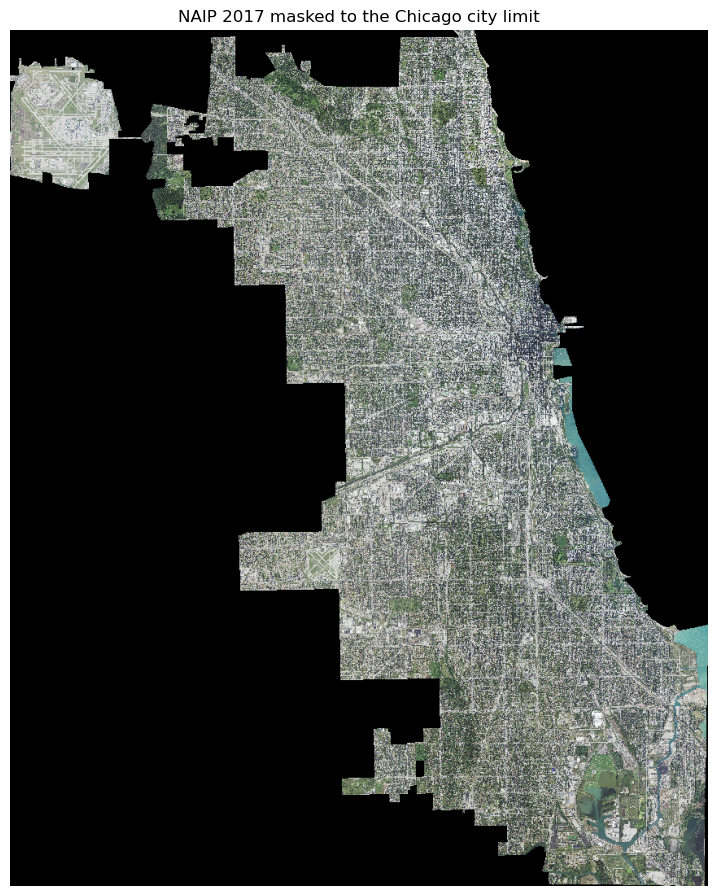

In [16]:
with rasterio.open(out_raster) as m:
    f = 40
    h, w = m.height // f, m.width // f
    rgb = np.dstack([m.read(1, out_shape=(h, w)),
                     m.read(2, out_shape=(h, w)),
                     m.read(3, out_shape=(h, w))])

plt.figure(figsize=(9, 12))
plt.imshow(rgb)
plt.title('NAIP 2017 masked to the Chicago city limit')
plt.axis('off')
plt.show()

## Step 4: Calculate the NDVI and the vegetation cover map

### 1. Chop the masked raster into small tiles

In [17]:
from rasterio.windows import Window

lu_dataset = rasterio.open('data/naip-chicago-masked.tif')
outfolder = 'data/naip-tiles'
os.makedirs(outfolder, exist_ok=True)

height, width = lu_dataset.shape
tile_size = 2000
tile_num_col = int(np.ceil(width / tile_size))
tile_num_row = int(np.ceil(height / tile_size))
print(f'raster {width} x {height} -> {tile_num_row} rows x {tile_num_col} cols of tiles')

for i in range(tile_num_row):
    for j in range(tile_num_col):
        row_end = min((i + 1) * tile_size, height)
        col_end = min((j + 1) * tile_size, width)
        window = Window(col_off=j * tile_size, row_off=i * tile_size,
                        width=col_end - j * tile_size, height=row_end - i * tile_size)

        kwargs = lu_dataset.meta.copy()
        kwargs.update({'height': window.height,
                       'width': window.width,
                       'transform': rasterio.windows.transform(window, lu_dataset.transform)})
        tilename = os.path.join(outfolder, 'row%s-col%s.tif' % (i, j))
        with rasterio.open(tilename, 'w', **kwargs) as dst:
            dst.write(lu_dataset.read(window=window))

print('tiles written:', len(glob.glob(os.path.join(outfolder, '*.tif'))))

raster 34339 x 42136 -> 22 rows x 18 cols of tiles
tiles written: 396


### 2. NDVI and vegetation cover per tile

In [18]:
infolder = 'data/naip-tiles'
outfolder = 'data/veg-tiles'
os.makedirs(outfolder, exist_ok=True)

for file in sorted(os.listdir(infolder)):
    if not file.endswith('.tif'):
        continue
    tiffile = os.path.join(infolder, file)

    with rasterio.open(tiffile) as naip_dataset:
        red = np.float32(naip_dataset.read(1))     # band 1 = Red
        nir = np.float32(naip_dataset.read(4))     # band 4 = NIR
        out_meta = naip_dataset.meta.copy()

    ndvi = (nir - red) / (nir + red + 1e-6)

    veg = np.zeros(ndvi.shape, dtype=np.uint8)
    veg[ndvi > 0] = 1

    out_meta.update({'count': 1, 'dtype': 'uint8', 'compress': 'lzw'})
    out_tif = os.path.join(outfolder, file)
    with rasterio.open(out_tif, 'w', **out_meta) as dest:
        dest.write(veg.reshape(1, veg.shape[0], veg.shape[1]))

print('veg tiles written:', len(glob.glob(os.path.join(outfolder, '*.tif'))))

veg tiles written: 396


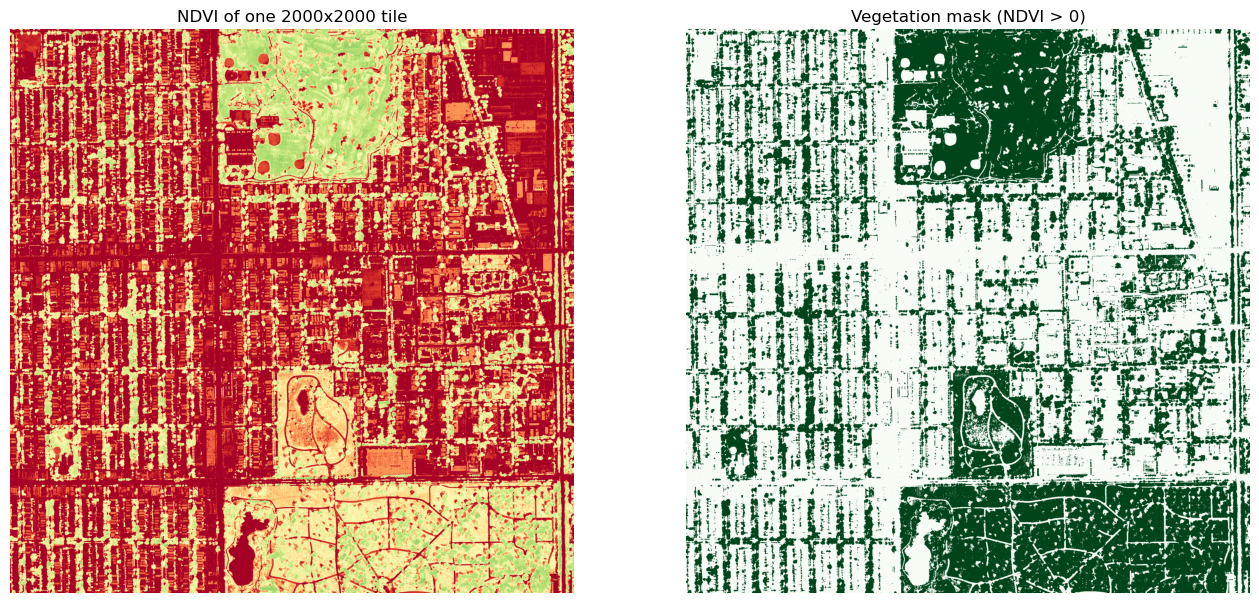

In [19]:
tiles = sorted(glob.glob('data/naip-tiles/*.tif'))
def valid_frac(t):
    with rasterio.open(t) as ds:
        return (ds.read(1) > 0).mean()
sample = max(tiles, key=valid_frac)
with rasterio.open(sample) as ds:
    red = np.float32(ds.read(1)); nir = np.float32(ds.read(4))
    ndvi = (nir - red) / (nir + red + 1e-6)
with rasterio.open(sample.replace('naip-tiles', 'veg-tiles')) as ds:
    veg = ds.read(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-0.3, vmax=0.8)
axes[0].set_title('NDVI of one 2000x2000 tile')
axes[1].imshow(veg, cmap='Greens', vmin=0, vmax=1)
axes[1].set_title('Vegetation mask (NDVI > 0)')
for ax in axes: ax.axis('off')
plt.show()

## Step 5 — Census-tract-level NDVI and vegetation cover maps

### 5.1 Zonal statistics

For each of the 874 Chicago census tracts: clip the masked NAIP raster to the tract
(a small windowed read), compute NDVI inside it, and record

* `ndvi` — mean NDVI over the tract's pixels (0 = outside-city fill is excluded via
  `count_nonzero`, the same trick as the demo);
* `vegcover` — fraction of pixels with NDVI > 0, i.e. vegetation cover in %.

In [20]:
inraster = 'data/naip-chicago-masked.tif'
input_zone_polygon = 'data/chicago-tract-26916.shp'
output_shp_res = 'data/chicago-vegcover-tract.shp'

naip_dataset = rasterio.open(inraster)
lyr = fiona.open(input_zone_polygon)
schema = lyr.schema
schema['properties']['ndvi'] = 'float'
schema['properties']['vegcover'] = 'float'

with fiona.open(output_shp_res, 'w', driver='ESRI Shapefile',
               crs=lyr.crs, schema=schema) as output:
    for idx, feat in enumerate(lyr):
        props = feat['properties']
        geom = [feat['geometry']]        # rasterio.mask wants a list

        outNAIP_image, out_transform = rasterio.mask.mask(
            naip_dataset, geom, nodata=0, crop=True)

        red = np.float32(outNAIP_image[0, :, :])   # band 1 = Red
        nir = np.float32(outNAIP_image[3, :, :])   # band 4 = NIR
        ndvi = (nir - red) / (nir + red + 1e-6)

        valid = (red > 0) | (nir > 0)
        if valid.sum() > 0:
            mean_val = float(ndvi[valid].mean())
            veg_pct  = float((ndvi[valid] > 0).mean() * 100)
        else:
            mean_val = None
            veg_pct  = None

        props['ndvi'] = mean_val
        props['vegcover'] = veg_pct
        output.write({'properties': props, 'geometry': feat['geometry']})

print('zonal statistics written to', output_shp_res)

/var/folders/zf/7t77k0k50dx4h1l7cgmkyhl00000gn/T/ipykernel_77745/943613619.py:32: FionaDeprecationWarning: instances of this class -- CRS, geometry, and feature objects -- will become immutable in fiona version 2.0
  props['ndvi'] = mean_val
/var/folders/zf/7t77k0k50dx4h1l7cgmkyhl00000gn/T/ipykernel_77745/943613619.py:33: FionaDeprecationWarning: instances of this class -- CRS, geometry, and feature objects -- will become immutable in fiona version 2.0
  props['vegcover'] = veg_pct
/var/folders/zf/7t77k0k50dx4h1l7cgmkyhl00000gn/T/ipykernel_77745/943613619.py:32: FionaDeprecationWarning: instances of this class -- CRS, geometry, and feature objects -- will become immutable in fiona version 2.0
  props['ndvi'] = mean_val
/var/folders/zf/7t77k0k50dx4h1l7cgmkyhl00000gn/T/ipykernel_77745/943613619.py:33: FionaDeprecationWarning: instances of this class -- CRS, geometry, and feature objects -- will become immutable in fiona version 2.0
  props['vegcover'] = veg_pct
/var/folders/zf/7t77k0k50d

zonal statistics written to data/chicago-vegcover-tract.shp


/var/folders/zf/7t77k0k50dx4h1l7cgmkyhl00000gn/T/ipykernel_77745/943613619.py:32: FionaDeprecationWarning: instances of this class -- CRS, geometry, and feature objects -- will become immutable in fiona version 2.0
  props['ndvi'] = mean_val
/var/folders/zf/7t77k0k50dx4h1l7cgmkyhl00000gn/T/ipykernel_77745/943613619.py:33: FionaDeprecationWarning: instances of this class -- CRS, geometry, and feature objects -- will become immutable in fiona version 2.0
  props['vegcover'] = veg_pct
/var/folders/zf/7t77k0k50dx4h1l7cgmkyhl00000gn/T/ipykernel_77745/943613619.py:32: FionaDeprecationWarning: instances of this class -- CRS, geometry, and feature objects -- will become immutable in fiona version 2.0
  props['ndvi'] = mean_val
/var/folders/zf/7t77k0k50dx4h1l7cgmkyhl00000gn/T/ipykernel_77745/943613619.py:33: FionaDeprecationWarning: instances of this class -- CRS, geometry, and feature objects -- will become immutable in fiona version 2.0
  props['vegcover'] = veg_pct


### 5.2 The maps

In [21]:
res = gpd.read_file('data/chicago-vegcover-tract.shp')
print('tracts:', len(res))
res[['NAMELSAD', 'ndvi', 'vegcover']].sort_values('vegcover').head()

tracts: 839


,NAMELSAD,ndvi,vegcover
711,Census Tract 815,-0.597166,1.642738
209,Census Tract 8391,-0.615041,2.333304
712,Census Tract 816,-0.601255,2.768651
481,Census Tract 814.03,-0.621966,3.181610
713,Census Tract 817,-0.551573,3.368686


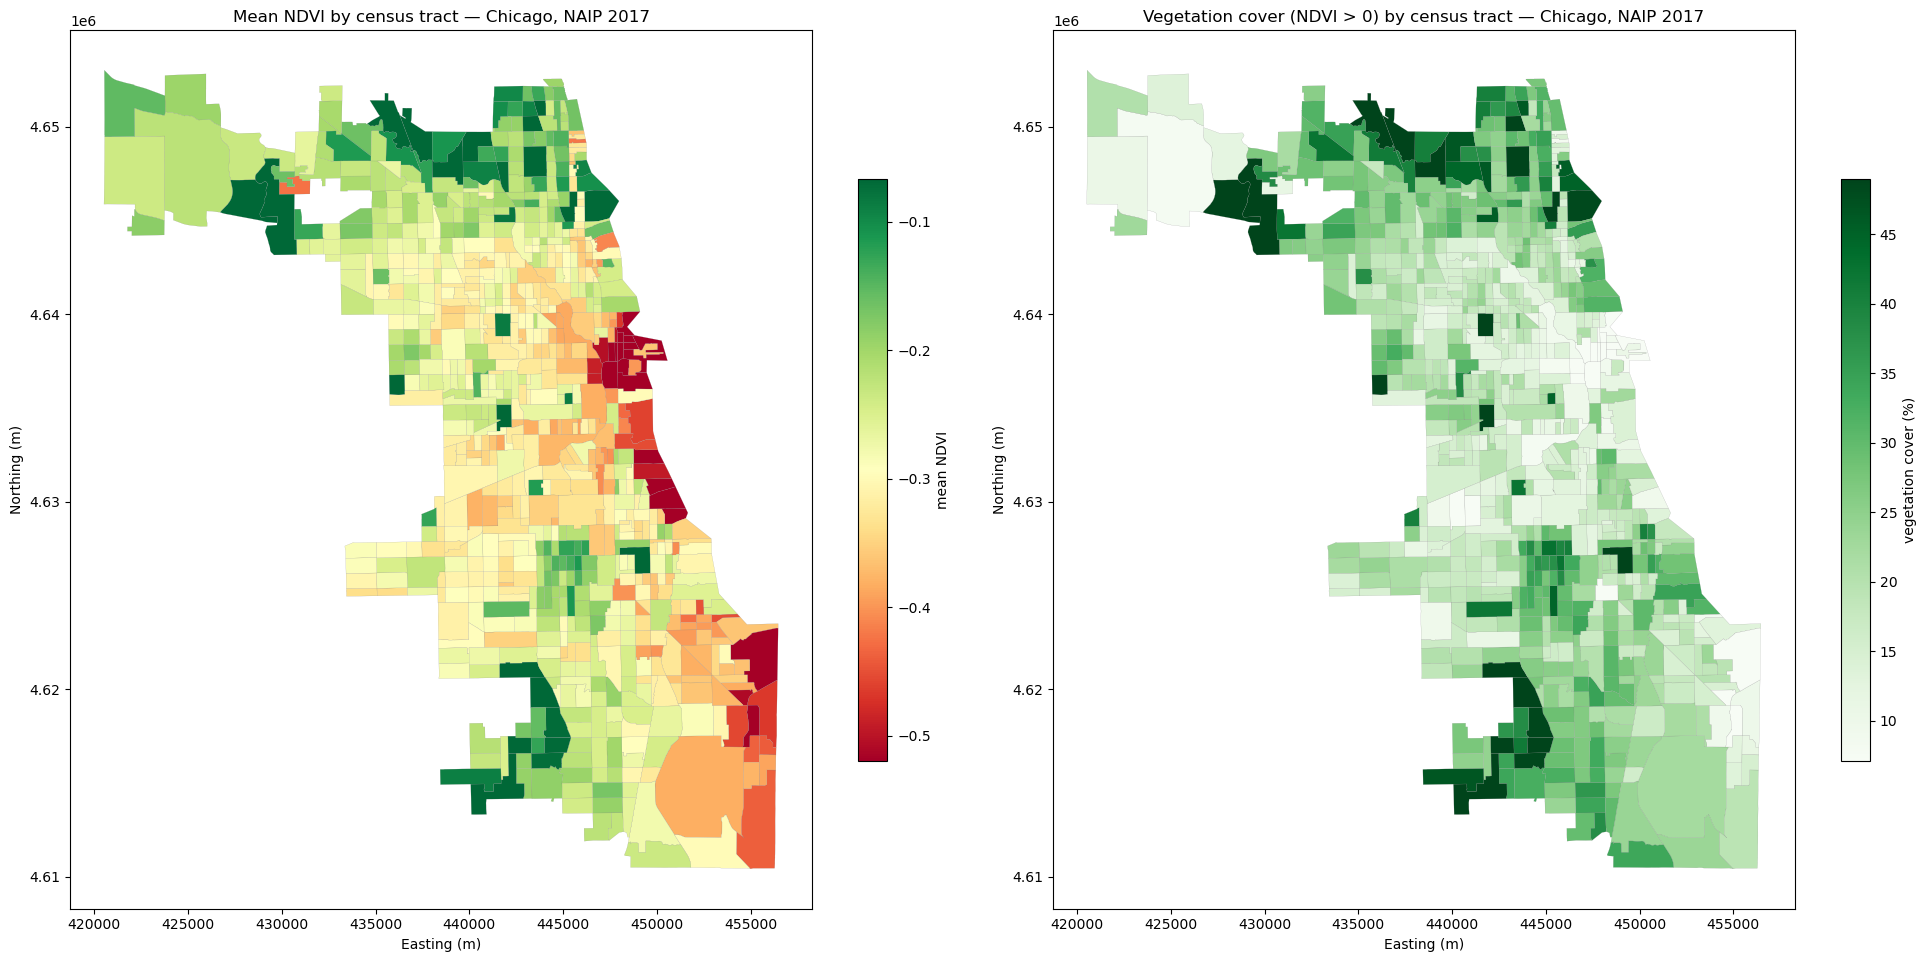

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

vmin, vmax = res['ndvi'].quantile(0.02), res['ndvi'].quantile(0.98)
res.plot(ax=axes[0], column='ndvi', cmap='RdYlGn', vmin=vmin, vmax=vmax,
         linewidth=0.1, edgecolor='grey', legend=True,
         legend_kwds={'label': 'mean NDVI', 'shrink': 0.6})
axes[0].set_title('Mean NDVI by census tract — Chicago, NAIP 2017')

vmin, vmax = res['vegcover'].quantile(0.02), res['vegcover'].quantile(0.98)
res.plot(ax=axes[1], column='vegcover', cmap='Greens', vmin=vmin, vmax=vmax,
         linewidth=0.1, edgecolor='grey', legend=True,
         legend_kwds={'label': 'vegetation cover (%)', 'shrink': 0.6})
axes[1].set_title('Vegetation cover (NDVI > 0) by census tract — Chicago, NAIP 2017')

for ax in axes:
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

6 Discussion

The two maps agree on the spatial pattern. The vegetation-cover map (share of pixels with NDVI > 0) shows: from 0% in the dense downtown Loop and the industrial near-south tracts to ~75% in tracts dominated by large open spaces. Citywide mean vegetation cover is ~20.5% (median tract ~19.8%), close to Chicago's often-quoted ~19% tree-canopy figure; the greenest quarter of tracts exceeds ~26%.

The greenest tracts are the big open spaces — Tract 7608.02 (O'Hare grassland, 75%), Tract 1201 (Grant Park / Museum Campus, 67%) and the far-southeast lakefill tracts (~58-63%). The least vegetated tracts (0-5%) are concentrated in the Central Business District and the industrial corridor south of it. A few tracts (airport edges, rail yards) have almost no overlap with the masked raster and are reported as 0.